<a href="https://colab.research.google.com/github/deviramesh7310-dotcom/Yuva-Logistics-Task/blob/main/Technical_%26_Operational.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# WEEK 4: PREDICTIVE MODELING & OPTIMIZATION IN LOGISTICS SYSTEMS
# Advanced Machine Learning & Route Optimization Framework
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
# Set seed for exact reproducibility
np.random.seed(42)

In [3]:
# 1. ADVANCED LOGISTICS DATA SIMULATION (5,000 Records)
n_samples = 5000

distance_km = np.random.uniform(10, 500, n_samples)
traffic_density = np.random.uniform(1, 10, n_samples)       # 1: Free Flow, 10: Heavy Congestion
weather_severity = np.random.uniform(1, 5, n_samples)        # 1: Clear, 5: Extreme Weather / Storm
package_weight_kg = np.random.uniform(1, 50, n_samples)
vehicle_factor = np.random.choice([1.0, 1.2, 1.5], size=n_samples) # 1.0: Bike, 1.2: Van, 1.5: Heavy Truck

In [4]:
# Target Variable Formula with Complex Interaction Terms
base_transit_time = (distance_km / 40.0) * vehicle_factor
traffic_delay = (traffic_density ** 1.3) * 0.15
weather_delay = (weather_severity ** 1.2) * 0.25
weight_impact = package_weight_kg * 0.015
noise = np.random.normal(0, 0.4, n_samples)

delivery_time_hrs = base_transit_time + traffic_delay + weather_delay + weight_impact + noise

In [5]:
# Construct DataFrame
df = pd.DataFrame({
    'distance_km': distance_km,
    'traffic_density': traffic_density,
    'weather_severity': weather_severity,
    'package_weight_kg': package_weight_kg,
    'vehicle_factor': vehicle_factor,
    'delivery_time_hrs': delivery_time_hrs
})

print("Dataset Simulated Successfully! Shape:", df.shape)

Dataset Simulated Successfully! Shape: (5000, 6)


In [6]:
# 2. DATA SPLITTING & PREPARATION
X = df.drop(columns=['delivery_time_hrs'])
y = df['delivery_time_hrs']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
# 3. MODEL TRAINING
# Model A: Baseline Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
# Model B: Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [8]:
# 4. HYPERPARAMETER TUNING (GridSearchCV)
param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test)

In [9]:
# 5. MODEL EVALUATION & COMPARISON METRICS
def get_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return round(rmse, 3), round(mae, 3), round(r2, 4)

results = pd.DataFrame([
    ['Linear Regression', *get_metrics(y_test, y_pred_lr)],
    ['Random Forest (Default)', *get_metrics(y_test, y_pred_rf)],
    ['Tuned Random Forest', *get_metrics(y_test, y_pred_tuned)]
], columns=['Model Architecture', 'RMSE (Hours)', 'MAE (Hours)', 'R2 Score'])

print("\n--- PERFORMANCE EVALUATION MATRIX ---")
print(results)


--- PERFORMANCE EVALUATION MATRIX ---
        Model Architecture  RMSE (Hours)  MAE (Hours)  R2 Score
0        Linear Regression         0.863        0.689    0.9674
1  Random Forest (Default)         0.521        0.410    0.9881
2      Tuned Random Forest         0.520        0.409    0.9882


/tmp/ipykernel_2127/2495493873.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=features, palette='mako')


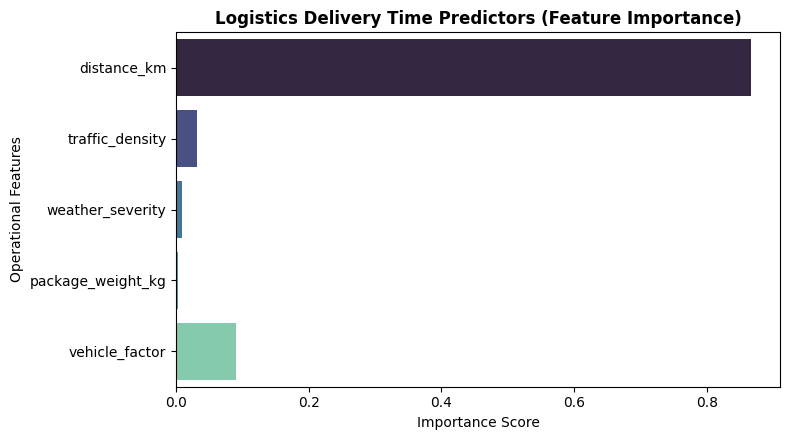

In [10]:
# 6. FEATURE IMPORTANCE VISUALIZATION
importances = best_rf.feature_importances_
features = X.columns

plt.figure(figsize=(8, 4.5))
sns.barplot(x=importances, y=features, palette='mako')
plt.title('Logistics Delivery Time Predictors (Feature Importance)', fontsize=12, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Operational Features')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300)
plt.show()